In [1]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(11)

# Linear Regression

In [2]:
X_LN = np.array([[40, 42, 43, 45, 48, 51, 55, 58, 62, 66, 67, 71, 77, 80, 88]]).T
y_LN = np.array([[133, 135, 135, 136, 144, 149, 152, 155, 159, 163, 169, 179, 180, 182, 188]]).T

one_LN = np.ones((X_LN.shape[0], 1))
Xbar_LN = np.concatenate((one_LN, X_LN), axis = 1)

[[83.1465655  1.2450185]]


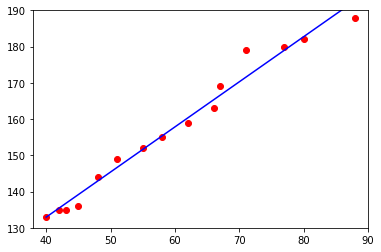

In [3]:
from sklearn import linear_model

regr_LN = linear_model.LinearRegression(fit_intercept = False)
regr_LN.fit(Xbar_LN, y_LN)

print(regr_LN.coef_)

y_pred_LN = regr_LN.predict(Xbar_LN)

plt.plot(X_LN[:, 0], y_LN[:, 0], 'ro')
plt.plot(Xbar_LN, y_pred_LN, 'b')
plt.axis([38, 90, 130, 190])
plt.show()

# K-means Clustering

In [4]:
means = [(2, 2), (8, 3), (3, 6)]
cov_KmC = [[1, 0], [0, 1]]
N = 500
K = 3

X0_KmC = np.random.multivariate_normal(means[0], cov_KmC, size = N)
X1_KmC = np.random.multivariate_normal(means[1], cov_KmC, size = N)
X2_KmC = np.random.multivariate_normal(means[2], cov_KmC, size = N)

X_KmC = np.concatenate((X0_KmC, X1_KmC, X2_KmC), axis = 0)

[[8.0410628  3.02094748]
 [1.97689714 2.00258549]
 [2.98896909 6.0286196 ]]
[[8.0410628  3.02094748]
 [1.97689714 2.00258549]
 [2.98896909 6.0286196 ]]


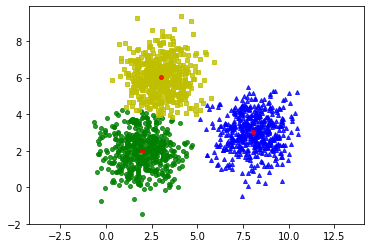

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, random_state = 0).fit(X_KmC)
print(kmeans.cluster_centers_)
pred_label_KmC = kmeans.predict(X_KmC)

centers_KmC = kmeans.cluster_centers_
print(centers_KmC)

def kmeans_display(X, label, centers):
    K = np.amax(label) + 1
    X0 = X[label == 0, :]
    X1 = X[label == 1, :]
    X2 = X[label == 2, :]
    
    plt.plot(X0[:, 0], X0[:, 1], "b^", markersize = 4, alpha = 0.8)
    plt.plot(X1[:, 0], X1[:, 1], "go", markersize = 4, alpha = 0.8)
    plt.plot(X2[:, 0], X2[:, 1], "ys", markersize = 4, alpha = 0.8)
    plt.plot(centers[:, 0], centers[:, -1], 'ro', markersize = 4, alpha = 0.8)

    plt.axis("equal")
    plt.show()

kmeans_display(X_KmC, pred_label_KmC, centers_KmC)

# K-nearest Neighbors

In [6]:
from sklearn import datasets, neighbors
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

ir = datasets.load_iris()
X_KnN = ir.data
y_KnN = ir.target

X_train_KnN, X_test_KnN, y_train_KnN, y_test_KnN = train_test_split(X_KnN, y_KnN, test_size = 1 / 3)

KnN = neighbors.KNeighborsClassifier(n_neighbors = 10, p = 2, algorithm = 'kd_tree', weights = 'distance')
KnN.fit(X_train_KnN, y_train_KnN)
y_pred_KnN = KnN.predict(X_test_KnN)

result = accuracy_score(y_pred_KnN, y_test_KnN) * 100
print(result)

98.0
